# LDS Non-EV submodel — EM fit

Fits the per-home daily LDS Non-EV submodel (`models/graphical_model/non_ev_lds.py`)
directly on labeled ground-truth Non-EV training observations — independent of
the EV side.

Per-home daily latent $z^{LDS,(n)}_d \in \mathbb{R}^T$ evolves as a LDS across days:

$$z^{LDS}_1 \sim \mathcal{N}(\mu_0, \Sigma_0), \quad z^{LDS}_d \sim \mathcal{N}(A z^{LDS}_{d-1}, Q), \quad x^{NonEV}_d \sim \mathcal{N}(C z^{LDS}_d, R)$$

Default instantiation: $A=I$, $C=I$, diagonal $Q$, $R$, $\Sigma_0$. EM updates
$\mu_0$, $\Sigma_0$, $Q$, $R$; $A$ and $C$ held fixed unless flagged otherwise.

Notebook structure:
1. Imports and data
2. Fit (`fit_lds_em`)
3. Diagnostics: log-likelihood trace, learned diag(Q), diag(R), $\mu_0$
4. Save fitted params (pickle)

## 1. Imports and data

In [1]:
import sys, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Make project root importable
PROJECT_ROOT = Path('../..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'notebooks' / 'utils'))

from data_utils import load_split
from models import graphical_model as gm
from models.graphical_model.non_ev_lds import fit_lds_em, LDSParams

In [2]:
# Load the training split (flat dataframe).
train_df = load_split(str(PROJECT_ROOT / 'data_processing' / 'splits' / 'train.pkl'))
print(f'rows={len(train_df):,}  homes={train_df.home_id.nunique()}')
train_df.head(2)

rows=1,543,872  homes=54


,total_load,ev_load,charge_state,non_ev_load,home_id,has_ev,city,day,time,time_index
76,2.193533,0.0,0,2.193533,3000,True,newyork,2019-05-02 00:00:00+00:00,0 days 00:00:00,0
77,2.557867,0.0,0,2.557867,3000,True,newyork,2019-05-02 00:00:00+00:00,0 days 00:15:00,1


In [3]:
# Build the per-home list of (D_n, T) Non-EV observation arrays.
# This is the input the LDS EM expects — one (D_n, T) array per home.
T = gm.T

nonev_obs_per_home = []
home_id_order      = []
for hid, g in train_df.sort_values(['home_id','day','time_index']).groupby('home_id'):
    D_n = g['day'].nunique()
    if len(g) != D_n * T:
        continue  # skip incomplete homes
    nev = g['non_ev_load'].to_numpy().reshape(D_n, T).astype(np.float64)
    nonev_obs_per_home.append(nev)
    home_id_order.append(int(hid))

print(f'N homes: {len(nonev_obs_per_home)}')
print(f'D_n range: {min(o.shape[0] for o in nonev_obs_per_home)} – {max(o.shape[0] for o in nonev_obs_per_home)}')
print(f'Total home-days: {sum(o.shape[0] for o in nonev_obs_per_home)}')

N homes: 54
D_n range: 182 – 361
Total home-days: 16082


## 2. Fit the LDS via EM

Defaults: $A=I_T$, $C=I_T$ held fixed; diagonal $Q$, $R$, $\Sigma_0$. To
experiment with relaxing constraints, flip `fit_A`, `fit_C`, or `diagonal_*=False`.

In [6]:
# Track per-iter logL by patching the EM loop's verbose output, or just re-run
# with a small max_iters and call fit_lds_em multiple times for a trace.
# Simpler: call once with max_iters big enough, then read the logL from the
# fitted params' Kalman filter on the data after the fact.

MAX_ITERS = 20
lds = fit_lds_em(
    nonev_obs_per_home,
    latent_dim       = T,
    fit_A            = False, # Fixed to identity
    fit_C            = False, # Fixed to identity
    diagonal_Q       = True, # Fixed to diagonal
    diagonal_R       = True, # Fixed to diagonal
    diagonal_Sigma_0 = True, # Fixed to diagonal
    max_iters        = MAX_ITERS,
    tol              = 1e-4,
    verbose          = True,
)

FIT: LDS via EM
  N_homes=54, total_days=16082, obs_dim=96, latent_dim=96
  fit_A=False, fit_C=False, diagonal(Q/R/Σ₀)=(True,True,True)
  iter   0:  logL = -2395570.260  Δ = +inf    (Q̄ diag = 0.6568, R̄ diag = 0.6464)
  iter   1:  logL = -2176486.728  Δ = +2.191e+05    (Q̄ diag = 0.4649, R̄ diag = 0.4894)
  iter   2:  logL = -2046795.216  Δ = +1.297e+05    (Q̄ diag = 0.3571, R̄ diag = 0.4207)
  iter   3:  logL = -1978533.199  Δ = +6.826e+04    (Q̄ diag = 0.2922, R̄ diag = 0.3952)
  iter   4:  logL = -1943886.972  Δ = +3.465e+04    (Q̄ diag = 0.2490, R̄ diag = 0.3909)
  iter   5:  logL = -1924059.011  Δ = +1.983e+04    (Q̄ diag = 0.2173, R̄ diag = 0.3968)
  iter   6:  logL = -1910033.159  Δ = +1.403e+04    (Q̄ diag = 0.1923, R̄ diag = 0.4068)
  iter   7:  logL = -1898533.224  Δ = +1.150e+04    (Q̄ diag = 0.1718, R̄ diag = 0.4179)
  iter   8:  logL = -1888550.533  Δ = +9.983e+03    (Q̄ diag = 0.1546, R̄ diag = 0.4286)
  iter   9:  logL = -1879746.937  Δ = +8.804e+03    (Q̄ diag = 0.1399

## 3. Diagnostics

### 3a. Marginal log-likelihood after fit

Per-home and total log $p(x^{NonEV}_{1:D_n})$ under the fitted LDS. Higher
is better; gives a single-number quality summary.

In [7]:
per_home_ll = np.array([lds.loglik(o) for o in nonev_obs_per_home])
per_home_D  = np.array([o.shape[0] for o in nonev_obs_per_home])
ll_per_day  = per_home_ll / per_home_D

print(f'Total log p(x^NonEV)           = {per_home_ll.sum():+.1f}')
print(f'Mean per-home log p             = {per_home_ll.mean():+.1f}')
print(f'Mean per-(home,day) log p       = {(per_home_ll.sum()/per_home_D.sum()):+.3f}')
print(f'Per-(home,day) log p  min/med/max = '
      f'{ll_per_day.min():+.2f} / {np.median(ll_per_day):+.2f} / {ll_per_day.max():+.2f}')

Total log p(x^NonEV)           = -1826969.3
Mean per-home log p             = -33832.8
Mean per-(home,day) log p       = -113.603
Per-(home,day) log p  min/med/max = -328.91 / -99.48 / -70.13


### 3b. Learned $\mu_0$ (initial-day mean profile)

Under $C=I$, $\mu_0$ is the model's expected Non-EV profile at $d=1$
(i.e. "day 0 of recording"). Should look like a typical residential
intraday load shape.

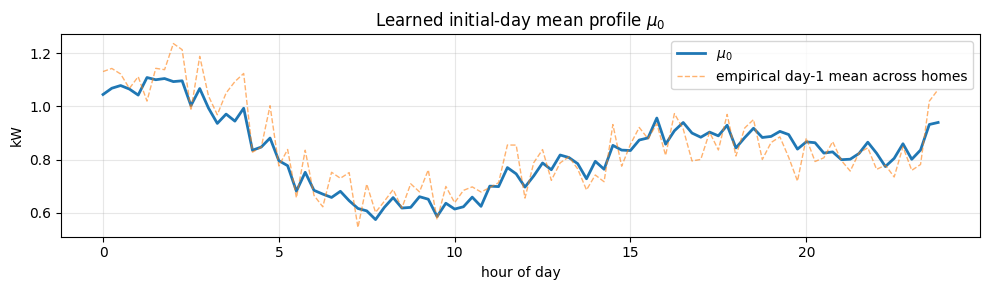

In [8]:
fig, ax = plt.subplots(figsize=(10, 3))
tt = np.arange(T) * 15 / 60   # hours of day
ax.plot(tt, lds.mu_0, lw=2, label=r'$\mu_0$')
# Overlay: empirical mean of day-1 Non-EV across homes
day1_mean = np.mean([o[0] for o in nonev_obs_per_home], axis=0)
ax.plot(tt, day1_mean, lw=1, ls='--', alpha=0.6, label='empirical day-1 mean across homes')
ax.set_xlabel('hour of day'); ax.set_ylabel('kW')
ax.set_title(r'Learned initial-day mean profile $\mu_0$')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 3c. Learned $\text{diag}(Q)$ and $\text{diag}(R)$

$Q[t,t]$ is the day-to-day random-walk innovation variance per time-of-day
(under $A=I$). $R[t,t]$ is the per-cell observation variance.

Their relative size matters: small $Q/R$ means the latent profile is
slowly-drifting and observations are noisy; large $Q/R$ means the latent
tracks observations almost cell-by-cell.

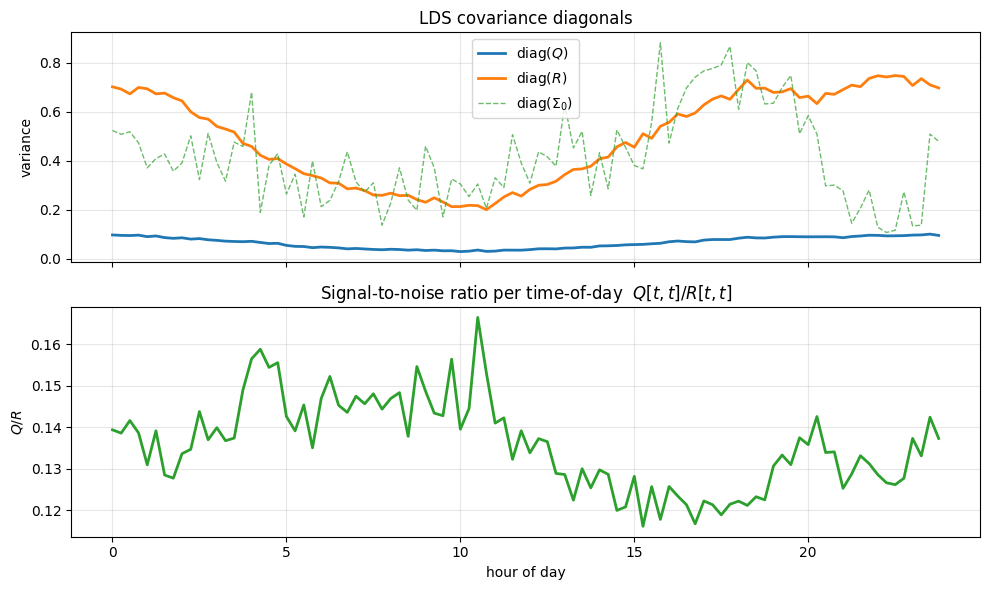

In [9]:
Q_diag = np.diag(lds.Q)
R_diag = np.diag(lds.R)
S0_diag = np.diag(lds.Sigma_0)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(tt, Q_diag, label=r'$\mathrm{diag}(Q)$',         lw=2)
axes[0].plot(tt, R_diag, label=r'$\mathrm{diag}(R)$',         lw=2)
axes[0].plot(tt, S0_diag, label=r'$\mathrm{diag}(\Sigma_0)$', lw=1, ls='--', alpha=0.7)
axes[0].set_ylabel('variance'); axes[0].set_title('LDS covariance diagonals')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(tt, Q_diag / np.maximum(R_diag, 1e-12), lw=2, color='C2')
axes[1].set_xlabel('hour of day'); axes[1].set_ylabel(r'$Q/R$')
axes[1].set_title('Signal-to-noise ratio per time-of-day  $Q[t,t] / R[t,t]$')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 3d. Per-home log-likelihood histogram

Reveals outlier homes the LDS fits poorly.

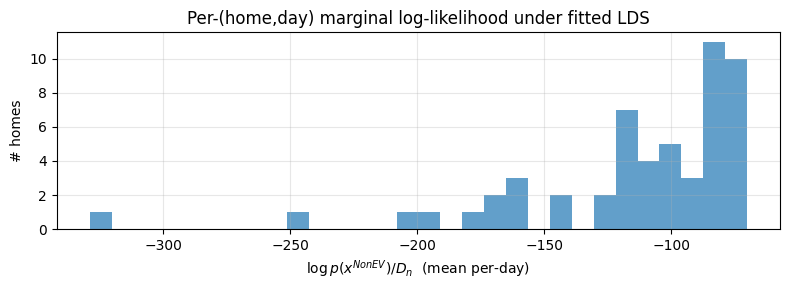

Worst 5 homes (lowest per-day logL):
  home    950  D= 183  logL/day=-328.91
  home   1240  D= 183  logL/day=-247.96
  home   7951  D= 360  logL/day=-202.52
  home   3039  D= 341  logL/day=-197.02
  home   2361  D= 358  logL/day=-180.35

Best 5 homes (highest per-day logL):
  home   5938  D= 361  logL/day=-70.13
  home   3700  D= 183  logL/day=-71.61
  home   9836  D= 353  logL/day=-72.79
  home   3938  D= 361  logL/day=-73.07
  home   6377  D= 360  logL/day=-76.13


In [10]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ll_per_day, bins=30, color='C0', alpha=0.7)
ax.set_xlabel(r'$\log p(x^{NonEV}) / D_n$  (mean per-day)'); ax.set_ylabel('# homes')
ax.set_title('Per-(home,day) marginal log-likelihood under fitted LDS')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Print the worst- and best-fit homes for the validation notebook to grab.
order = np.argsort(ll_per_day)
print('Worst 5 homes (lowest per-day logL):')
for i in order[:5]:
    print(f'  home {home_id_order[i]:>6}  D={per_home_D[i]:>4}  '
          f'logL/day={ll_per_day[i]:+.2f}')
print('\nBest 5 homes (highest per-day logL):')
for i in order[-5:][::-1]:
    print(f'  home {home_id_order[i]:>6}  D={per_home_D[i]:>4}  '
          f'logL/day={ll_per_day[i]:+.2f}')

## 4. Save fitted LDS params

Pickled to `models/lds_params.pkl`. The validation notebook loads from here.

In [11]:
out_path = PROJECT_ROOT / 'models' / 'lds_params.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(lds, f)
print(f'Saved LDSParams to {out_path}')

Saved LDSParams to /Users/jackhsieh/Downloads/residential-power-forecasting/models/lds_params.pkl
